<h1 style="font-size: 300%; font-weight: 100"><span style="font-size: 60%">Part 3:</span><br>$W$ mass measurement</h1>

<img src="notebook_figures/STDM-2014-18-fig_24a.png" alt="ATLAS 7TeV " width="500">

In this part of the ATLAS FP experiemnt we will perform the measurement of the W mass.
In contrast to the Z boson, a leptonically decaying W boson cannot be fully reconstructed. Therefore, the mass cannot be measured directly from the invariant mass as it was done in the previous part. Instead we can infare the information on the W mass from the distribution of variables that are sensitive to the mass. $p_{T}$ of the visible lepton is one of those (peaking at $p_T\sim m_{W}/2$), and the one that we will be using here, trying to reproduce [ATLAS results](https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/STDM-2014-18).

<div style="border: 1px solid black; padding: 1em">
    About this notebook: Tasks are marked with <b>Assignemnt</b>, places where
    you need to add code are marked with <code># TODO</code>.
</div>

In [2]:
#Running for the first time you might have to install additional packages (please uncomment line below)
#%pip install -r requirements.txt

In [3]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
from glob import glob

import uproot as up
import numpy as np
import scipy.interpolate as si
from scipy.stats import poisson
from scipy.stats import norm as gauss
import scipy.optimize
import matplotlib.pyplot as plt
from pylorentz import Momentum4
import atlasify as atl
atl.ATLAS = "FP2 - ATLAS"  # Do not remove
from atlasify import atlasify
from collections import OrderedDict
import itertools
import ROOT
import pandas as pd
import fputils as fpu

In [5]:
# Let's make sure we have a directory where we want to dump plots to
%mkdir -p plots

# Introduction

We will be using the same data samples as in Part2 (Zee calibration). However, this time we will also need simulated (often refered to as MC,i.e Monte Carlo) events to get expected distributions for different mass hypothesis. In practice it means that we have to deal with much more input files (ntuples). To organise our work we will be using `Analysis` class from the `fpu`. 

In [6]:
help(fpu.Analysis.add_sample)

Help on function add_sample in module fputils:

add_sample(
    self,
    name,
    label,
    files,
    xsec_fb=None,
    filter_efficiency=1,
    branching_ratio=1,
    meta_data=None
)



## MC samples

In the table below signal and dominant background relevant for our analysis are collected together with their generator-level cross sections (xsec), filter efficiency and the strings that will help you identifying the relevant files. The cross section tells us how likely a certain process is to be taking place inside the detector, at the given the given centre-of-mass energy. Most of the times when doing analysis we are interested only in a certain subset of all the events produced (like here, only on events with 1 electron). MC filters allows us to select only some subset of events at the low-level event generation (before expensive computationally detector simulation is run on). Filter efficiency tells us what is the ratio of events that were accepted and saved by MC generator. For example, the ttbar sample below was made with a (non-allhad) filter that rejects if any of the two top-quarks decays leptonically. Cucially, a MC generator uses for that 'truth' information that is not available in real data.  From cross section ($\sigma$), filter efficiency ($\epsilon$) and luminosity ($\mathcal{L}$) of the collider one can calculate expected number of events coming from a specific project as:

$$N=\sigma \cdot \mathcal{L} \cdot \epsilon$$

| sample      | xsec \[fb\]  | filter efficiency |  file(s)       |
| ----------- | -----------  | -----------       |  -----------   |  
| ttbar       | 177300       |   0.54259         |  v5.mc11_7TeV.105200.T1_McAtNlo_Jimmy       |
| WW          | 29563        |   0.349           |  v5.mc11_7TeV.105985.WW_Herwig              |
| ZZ          | 4596         |   0.2784          |  v5.mc11_7TeV.105986.ZZ_Herwig              |
| WZ          | 11245        |   0.1924          |  v5.mc11_7TeV.105987.WZ_Herwig              |
| Ztautau     | 8.486e05     |   1.0             |  v5.mc11_7TeV.106052.PythiaZtautau          |
| Wtaunu      | 8.824e6      |   1.0             |  v5.mc11_7TeV.107054.PythiaWtaunu_incl      |
| Wplusenu    | 6.16e6       |   1.0             |  v5.mc11_7TeV.108297.PowHegWplusenuPythia   |
| Wminenu     | 4.30e6       |   1.0             |  v5.mc11_7TeV.108300.PowHegWminenuPythia    |
| Zee         | 0.99e6       |   1.0             |  v5.mc11_7TeV.108303.PowHegZePythia          |

<b>Assignemnt 1)</b> Can you think about (LO) Feynmann diagrams that can lead to these processes?  
<b>Assignemnt 2)</b> Any idea why $\sigma(W\to e^+\nu)> \sigma(W\to e^-\nu)$? 

## First look into Data & MC

As before, it might be worth to have pandas dataframe for quick ntuple inspection

In [7]:
root_file = up.open("/home/cl313/test/ATLAS/data/ntuple_part23/v5.data11_7TeV.periodF.physics_Egamma.grp10_v01_p1035.root")
ttree = root_file["eventTree"]
dataframe = ttree.arrays(library='pd')



In [8]:
dataframe.columns

Index(['RunNumber', 'el_n', 'el1_cl_E', 'el1_cl_eta', 'el1_cl_phi',
       'el1_charge', 'el1_isMediumPP', 'el1_isTightPP', 'el1_isolation',
       'el2_cl_E', 'el2_cl_eta', 'el2_cl_phi', 'el2_charge', 'el2_isMediumPP',
       'el2_isTightPP', 'el2_isolation', 'MET', 'MET_phi', 'MET_sumEt',
       'jet_n', 'EF_e20_medium', 'EF_e22_medium', 'EF_e22vh_medium1'],
      dtype='str')

Now, let's start playing with Analysis object

In [9]:
# Luminosity of the data sample we are using is needed to correctly normalise our MC samples to it.
# Here we use ATLAS 7TeV data from Run1 corresponding to total integrated luminosity of ~4.6 fb-1

analysisFL = fpu.Analysis(luminosity_fb=4.57944)

# add_sample method attaches sample to the analysis object specifying its type (data/fake/MC background/MC signal)
# it accepts 'meta_data' dictionary that carries information on sample type

# Data
data_paths = sorted(glob("/home/cl313/test/ATLAS/data/ntuple_part23/v5.data11_7TeV.*.root"))
analysisFL.add_sample("data", "Data",
                    data_paths,
                    meta_data={"fake": False, "data": True, "mc": False, "W": False})
                    
# W -> e nu
analysisFL.add_sample("Wen", r"$W\rightarrow e\nu$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108297.PowHegWplusenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root"],
                    xsec_fb=6.16e6,
                    meta_data={"fake": False, "data": False, "mc": True, "W": True})
analysisFL.add_sample("Wen", r"$W\rightarrow e\nu$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108300.PowHegWminenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root"],
                    xsec_fb=4.30e6,
                    meta_data={"fake": False, "data": False, "mc": True, "W": True})

# t tbar
analysisFL.add_sample("ttbar", r"$t\bar{t}$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.105200.T1_McAtNlo_Jimmy.e835_s1272_s1274_r3043_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=0.54259,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})

The logic behind `Analysis` class is rather simple as it is effectively a list of samples we are interested in with their meta data. 

In [10]:
analysisFL.names

['data', 'Wen', 'Wen', 'ttbar']

Ntuples with the same names ($W^+$ and $W^-$ here under one name 'Wen') inside the class are combined.

The usefullness of the class come from `TH1F_stack` and `dataframe_iterate` functions which can be used in a similar manner 
as it was done in Part2 with `ROOT.TH1` and `fpu.dataframe_iterate` but now iterating over multiple samples!

In [11]:
h_met = analysisFL.TH1F_stack(40, 20, 100)
h_pt = analysisFL.TH1F_stack(45, 25, 70)

for df, norm, meta_data, i in analysisFL.dataframe_iterate(fraction=0.1):
    sel = df.el_n == 1
    sel &= ~df.el2_isMediumPP
    sel &= df.MET > 30_000
    
    df = df[sel]
    
    #compute and add pT to DataFrame
    df = df.assign(e1_pt=pd.Series(df.el1_cl_E / np.cosh(df.el1_cl_eta), index=df.index))
    weights=None
    if meta_data["mc"]:
        weights = df.mc_weight * norm
    else:
        weights = None
        
    fpu.fill_histo(df.MET / 1000, h_met[i], weights=weights)
    fpu.fill_histo(df.e1_pt / 1000, h_pt[i], weights=weights)

This produces len(set(analysisFL.names)) histograms, i.e. 3 in the example, in each kinematic variables.

Let's visualise the histograms

In [12]:
def split(histogram_stack):
    return histogram_stack[0], histogram_stack[1:]
def default_plot(histogram_stack, x_label, axes=None):
    if axes is None:
        fig, axes = plt.subplots()
        
    data, backgrounds = split(histogram_stack) # here we rely on data being added to `Analysis` class as the first one!
    fpu.hist_stack(*backgrounds, axes=axes)
    fpu.hist_points(data, axes=axes)
    fpu.reverse_legend()
    atl.atlasify(subtext="$W$ mass")
    axes.set_xlabel(x_label, ha='right', x=0.95)
    bin_width = backgrounds[0].GetXaxis().GetBinWidth(1)
    axes.set_ylabel(f"Events / {bin_width:g} GeV", ha='right', y=0.95)
    return axes

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2256/617552048.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  default_plot(h_met, "Missing transverse momentum $E_\mathrm{T}^{\mathrm{miss}}$ / GeV")


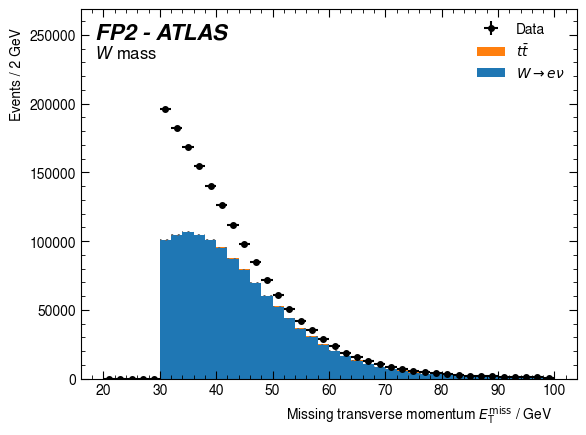

In [13]:
default_plot(h_met, "Missing transverse momentum $E_\mathrm{T}^{\mathrm{miss}}$ / GeV")
plt.savefig("plots/FL_MET.pdf")

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2256/3043634866.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  default_plot(h_pt, "$p_\mathrm{T}^{e_1}$ / GeV")


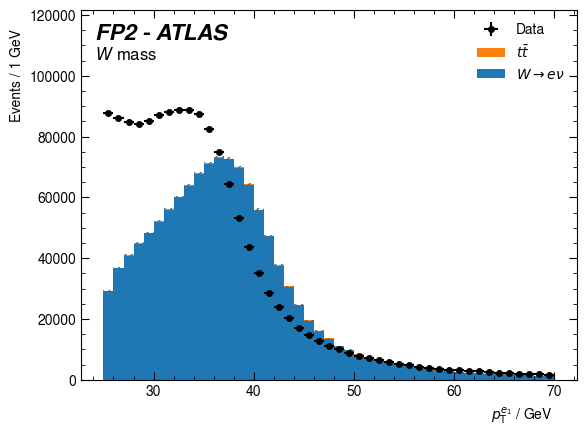

In [14]:
default_plot(h_pt, "$p_\mathrm{T}^{e_1}$ / GeV")
plt.savefig("plots/FL_e1_pt.pdf")

Hurray (if we see the plots) but also hmmm... the data/MC agreement does not seem to be great!

<b>Assignemnt</b> Take a moment to think what could have caused the discrepancy visible. 

*Understanding and/or debugging your inputs(ntuples) is important part of everyday work when working on an analysis.*

In the next part we will try to fix the agreemend between data and our expectations!


What could caus this discrepany. We see this discrepancy at low GeV, at low we have a higher cross sections so a lot more background that can be missidentified, also x shift, due to missign alpha correction

# Data & MC comparison - proper look

**Assignment:**  Please try to fill and improve the code below to get a good data/MC agreement and select primarily
$W\rightarrow e \nu$ events. Througout the task think about:
* what cuts are relevant to select $W\rightarrow e \nu$ events?
* which are the dominant background processes?
* is fake lepton background important? how should it be implemented, which samples used, what cuts need to be applied for that?

*Remember to document the cuts and finding at every stage*

## Sample specification

In [15]:
# Luminosity of the data sample we are using is needed to correctly normalise our MC samples to it.
# Here we use ATLAS 7TeV data from Run1 corresponding to total integrated luminosity of ~4.6 fb-1

analysis = fpu.Analysis(luminosity_fb=4.57944)

# add_sample method attaches sample to the analysis object specifying its type (data/fake/MC background/MC signal)

# Data
data_paths = sorted(glob("/home/cl313/test/ATLAS/data/ntuple_part23/v5.data11_7TeV.*.root"))
analysis.add_sample("data", "Data",
                    data_paths,
                    meta_data={"fake": False, "data": True, "mc": False, "W": False})
                    
# W -> e nu
analysis.add_sample("Wen", r"$W\rightarrow e\nu$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108297.PowHegWplusenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root"],
                    xsec_fb=6.16e6,
                    meta_data={"fake": False, "data": False, "mc": True, "W": True})
analysis.add_sample("Wen", r"$W\rightarrow e\nu$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108300.PowHegWminenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root"],
                    xsec_fb=4.30e6,
                    meta_data={"fake": False, "data": False, "mc": True, "W": True})

# Significant portion of background events are coming from multi-jet events where one of the jet fakes an electron . 
# Since multi-jet events have huge production cross section, and the jet-misstag rate is very small it is often not
# feasible to have a dedicated MC samples with fakes. We will be using data-driven techniques instead. 

# TODO Add sample needed for fake leptons estimation (see discussions below)
analysis.add_sample("fl", "fake leptons",
                    data_paths,
                    meta_data={"fake": True, "data": True, "mc": False, "W": False})


# t tbar
analysis.add_sample("ttbar", r"$t\bar{t}$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.105200.T1_McAtNlo_Jimmy.e835_s1272_s1274_r3043_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=0.54259,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})


# TODO add other samples available to the analysis object^


#WW
analysis.add_sample("WW", r"$WW$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.105985.WW_Herwig.e825_s1310_s1300_r3043_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=0.349,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})

#ZZ
analysis.add_sample("ZZ", r"$ZZ$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.105986.ZZ_Herwig.e825_s1310_s1300_r3043_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=0.2784,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})

#WZ
analysis.add_sample("WZ", r"$WZ$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.105987.WZ_Herwig.e825_s1310_s1300_r3043_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=0.1924,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})
#Ztautau
analysis.add_sample("Ztautau", r"$Z\tau\tau$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.106052.PythiaZtautau.e825_s1356_s1353_r3043_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=1,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})

#Wtautau
analysis.add_sample("Wtaunu", r"$W\tau\nu$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.107054.PythiaWtaunu_incl.e825_s1349_s1300_r3060_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=1,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})

#Zee
analysis.add_sample("Zee", r"$Zee$",
                    ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108303.PowHegZePythia.e825_s1372_s1370_r3043_r2993_p1035.root"],
                    xsec_fb=177_300, branching_ratio=1,
                    meta_data={"fake": False, "data": False, "mc": True, "W": False})


In [16]:
# Our fake estimation method will not yield correct normalisation
# For now we will assume a normalisation factor that we will determine in a fit later 

wh_fake_factor = 1  # Working hypothesis, ultimately to be determined in a fit

## Calibration loading

Here we load data calibration you have come up with in the previous part (Zee). 

In [17]:
try:
    alpha = np.load("alpha.npy")
    eta_edges = np.load("eta_edges.npy")   
except FileNotFoundError:
    print("<<<< You have not provided calibration! You should calibrate your data for final results! <<<< ")
    print("      For now we will proceed with no-calibration")
    alpha=np.array([0])
    eta_edges=np.array([0,2.5])

<<<< You have not provided calibration! You should calibrate your data for final results! <<<< 
      For now we will proceed with no-calibration


In [18]:
eta_edges = np.array([0, 0.1, 0.2, 0.65, 0.8, 1.25, 1.45, 1.7, 1.8, 2.05, 2.15, 2.3, 2.4, 2.6])

In [19]:
alpha = np.array([-0.08601299 -0.08157528 -0.07987026 -0.08552496 -0.10733649 -0.11318788
 -0.11307805 -0.09287579 -0.09128619 -0.09391004 -0.09378338 -0.09567731
 -0.11021467])

## Helpful functions

Here we collect functions we will be using throughout the notebook. 
It goes without saying taht you are invited to modify those along your needs.

<b>Assignemnt</b> fix definition of mt 

In [20]:
# def pt(E, eta):
#     """
#     Computes and returns the transverse momentum of an electron. Please note
#     that the argument and return value can be arrays.
#     """
#     return E / np.cosh(eta)

def pt(E, eta, m_e= 0.5109989461):  
    
    return np.sqrt(E**2-m_e**2) / np.cosh(eta)


def apply_calib(E, eta, alpha=alpha, eta_edges=eta_edges):
    """
    Applies the energy callibration by using the the appropriate values from the
    alpha variable depending on eta. Please note that the arguments and return value are arrays.
    """
    alpha_array = np.zeros(len(E))

    eta_idx = np.searchsorted(eta_edges, eta.abs()) - 1
    for idx, a in enumerate(alpha):
        # We apply different alpha correction factors, one at a time, only to
        # events in the appropriate eta bin
        alpha_array[eta_idx == idx] = a
        
    # The entries in alpha_array are the alpha factors to the corresponding
    # events in the E and eta array.
        
    return E / (1 + alpha_array)

In [21]:
def mt(df):
    # df = df[df.el_n==1]

    #mt = np.sqrt(2*pt(apply_calib(df.el1_cl_E, df.el1_cl_eta),df.el1_cl_eta)*df.MET*(1-np.cos(df.el1_cl_phi -df.MET_phi)))

    mt = np.sqrt(2*pt(df.el1_cl_E,df.el1_cl_eta)*df.MET*(1-np.cos(df.el1_cl_phi -df.MET_phi)))

    return mt


    # """
    # Computes and returns the transverse mass of an electron. 
    # You can assume that electron and neutrino masses are neglidgible
    # """
    # # TODO Compute mT

    
    # theta1 = 2*np.arctan(np.exp(-df.el1_cl_eta))
    # theta2 = 2*np.arctan(np.exp(-df.el2_cl_eta))

    # Ecorr1 = apply_calib(df.el1_cl_E, df.el1_cl_eta)
    # Ecorr2 = apply_calib(df.el2_cl_E, df.el2_cl_eta)

    # Exmiss = Ecorr1*np.sin(theta1)* np.cos(df.el1_cl_phi) +Ecorr2*np.sin(theta2)* np.cos(df.el2_cl_phi)
    # Eymiss = Ecorr1*np.sin(theta1)* np.sin(df.el1_cl_phi) +Ecorr2*np.sin(theta2)* np.sin(df.el2_cl_phi)



    # mt = np.sqrt(Exmiss**2+Eymiss**2)
    # # print("<< You seeing this as you have not implemeted mt calculation!<<")
    # # print("<< Please fix function mt and remove this wornings. <<")


    

In [22]:
mt(df)

0            746.259338
2            896.831970
4          88144.242188
5          40159.878906
6          67442.406250
              ...      
330875     50479.433594
330876    110981.828125
330878     92825.250000
330879     70834.054688
330880     67170.296875
Length: 255572, dtype: float32

In [23]:
df.MET

0          67164.351562
2         125506.421875
4          52414.839844
5          34427.457031
6         157982.843750
              ...      
330875     99169.414062
330876     58433.808594
330878    154370.609375
330879     59740.671875
330880     71356.671875
Name: MET, Length: 255572, dtype: float32

In [24]:
def sum_histograms(histograms):
    """
    Returns ROOT.TH1 histogram with the sum of the input ROOT.TH1 histograms.
    Errors are added in quadratures.
    """
    result = histograms[0].Clone()
    result.Reset()
    result.SetTitle("")
    
    for histogram in histograms:
        result.Add(histogram)
    
    return result

In [25]:
def split(histogram_stack):
    """
    Splits histogram stack into data and backgrounds.
    Assumes data histogram is in the first place
    (data sample needs to be added as first with add_samples method)
    """
    return histogram_stack[0], histogram_stack[1:]

def default_plot(histogram_stack, x_label,y_label=None, axes=None):
    """
    Draws histograms for data & MC from histogram_stack
    
    Inputs:
        histogram_stack -- data hist must be on the first place
        x_label         -- x axis label
        
    optional inputs:
        y_label         -- y axis label
        axes            -- matplotlib.axes object where to plot
    """
    if axes is None:
        fig, axes = plt.subplots()
        
    data, backgrounds = split(histogram_stack)
    fpu.hist_stack(*backgrounds, axes=axes)
    fpu.hist_points(data, axes=axes)
    fpu.reverse_legend(axes=axes)
    atlasify(subtext="$W$ mass",axes=axes)
    axes.set_xlabel(x_label, ha='right', x=0.95)
    if(not y_label):
        bin_width = backgrounds[0].GetXaxis().GetBinWidth(1)
        y_label=f"Events / {bin_width:g} GeV"
    axes.set_ylabel(y_label, ha='right', y=0.95)
    return axes

In [26]:
def default_ratio_plot(histogram_stack, x_label,y_label=None,axes=(None,None)):
    """
    Draws histograms for data & MC from histogram_stack with data/MC ratio as well
    
    Inputs:
        histogram_stack -- data hist must be on the first place
        x_label         -- x axis label
        
    optional inputs:
        y_label         -- y axis label
        axes            -- matplotlib.axes object where to plot
    """
    
    if(None in axes):
        fig, (ax1, ax2) = plt.subplots(nrows=2, sharex='col', gridspec_kw={'height_ratios': [4, 1]})
    
    # Draw top panel using already define default_plot
    default_plot(histogram_stack, '',y_label=y_label, axes=ax1)    
    
    # Create ratio plot between data & mc
    # for this ROOT is amazingly simple
    data, backgrounds = split(histogram_stack)
    hBkg=sum_histograms(backgrounds)
    hRatio=histogram_stack[0].Clone()
    hRatio.Divide(hBkg)
    fpu.hist_points(hRatio, axes=ax2)

    ax2.set_xlabel(x_label, ha='right', x=0.95)
    ax2.set_ylabel('data/MC', ha='right', x=0.95)
    ax2.set_ylim(0.5,1.5)
    xLimits=[hRatio.GetXaxis().GetXmin(),hRatio.GetXaxis().GetXmax()]
    ax2.plot(xLimits,[1,1],ls=':',c='k')
    fig.align_ylabels()
    fig.tight_layout()
    return (ax1,ax2)

## Event selections & plotting

<b>Assignemnt</b> Fix event_selection function optimal for W mass measurement. Correct fake lepton estimation should also be worked out.

<b>Assignemnt</b> Verify your selection choice by plotting different kinematic distributions

In [27]:
def event_selection(df,meta_data):
    """
    Returns a new DataFrame with only a subset of events, selected for the
    analysis.
    """

    # TODO Think about general cuts that all events need to satisfy
    df = df[df.el_n ==1]
    df = df[pt(df.el1_cl_E, df.el1_cl_eta) > 28500]  
    df = df[df.MET > 25000]

    
    if meta_data["fake"]:
        # This is fake lepton event
        # TODO Come up with the cuts you should be applying to fake events
        df = df[~df.el1_isTightPP] 

        


    else:
        # data & all bkg except fake-laptons
        # TODO Come up with the cuts you should be applying non-fake leptons

        df = df[df.el1_isTightPP]
        df = df[df.el1_isolation < 0.1]
        # df = df[mt(df) > 40000]
        


    
    return df

In [28]:
help(analysis.TH1F_stack)

Help on method TH1F_stack in module fputils:

TH1F_stack(nbins, xmin, xmax) method of fputils.Analysis instance
    Returns a list of identical histogram, one histogram for each unique
    sample name.



In [29]:
# Define histogram stacks you want
# stacks and not just normal histograms as we want to have one histogram for each production process
h_met = analysis.TH1F_stack(40, 20, 100)
h_pt = analysis.TH1F_stack(45, 25, 70)
h_eta = analysis.TH1F_stack(50,-2.5,2.5)
h_chrg = analysis.TH1F_stack(5,-1,1)
h_mt = analysis.TH1F_stack(50,0,130)
h_dphi = analysis.TH1F_stack(100,0,2*np.pi)

for df, norm, meta_data, i in analysis.dataframe_iterate(fraction=1):
    
    # Apply cuts on events
    df=event_selection(df,meta_data)
    
    # Calibrate data
    if meta_data["data"]:
        e1_E_calib = fpu.apply_calib(df.el1_cl_E, df.el1_cl_eta, alpha, eta_edges)
    else:
        #MC should not be calibrated
        e1_E_calib = df.el1_cl_E
        
    #compute and add pT and mT to DataFrame
    df = df.assign(e1_pt=pd.Series(pt(e1_E_calib, df.el1_cl_eta), index=df.index))
    df = df.assign(mt=pd.Series(mt(df), index=df.index))
    df = df.assign(eta=pd.Series(df.el1_cl_eta, index=df.index))
    df = df.assign(chrg =pd.Series(df.el1_charge, index=df.index))
    df = df.assign(dphi =pd.Series(np.abs(df.el1_cl_phi - df.MET_phi), index=df.index))

    
    # Calculate correct event weight
    if meta_data["mc"]:
        weights = df.mc_weight * norm
    elif meta_data["fake"]:
        weights = np.ones(len(df)) * wh_fake_factor
    else:
        weights = None
        
    fpu.fill_histo(df.MET / 1000, h_met[i], weights=weights)
    fpu.fill_histo(df.e1_pt / 1000, h_pt[i], weights=weights)
    fpu.fill_histo(df.eta,h_eta[i], weights=weights )
    fpu.fill_histo(df.chrg, h_chrg[i], weights=weights)
    fpu.fill_histo(df.mt / 1000, h_mt[i], weights=weights)
    fpu.fill_histo(df.dphi, h_dphi[i], weights=weights)
    # TODO -- add more kinematic distributions verifying your selection is correct

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2256/2493243883.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  default_plot(h_met, "Missing transverse momentum $E_\mathrm{T}^{\mathrm{miss}}$ / GeV")


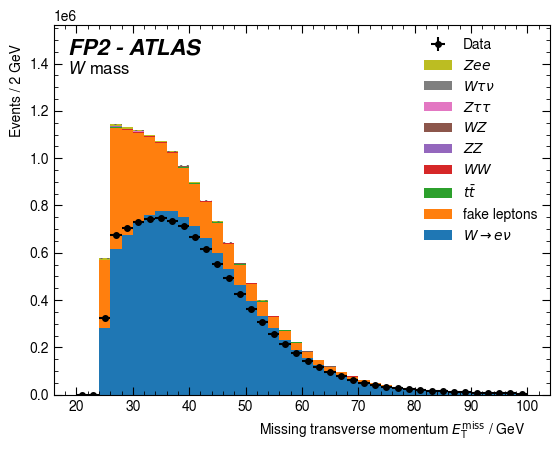

In [30]:
default_plot(h_met, "Missing transverse momentum $E_\mathrm{T}^{\mathrm{miss}}$ / GeV")
plt.savefig("plots/met_prefit.pdf")
None

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2256/231379732.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  default_plot(h_mt, "Transverse mass $E_\mathrm{T}^{\mathrm{miss}}$ / GeV")


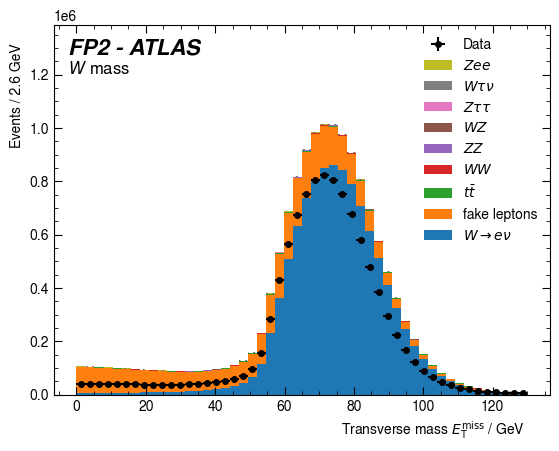

In [31]:
default_plot(h_mt, "Transverse mass $E_\mathrm{T}^{\mathrm{miss}}$ / GeV")
plt.savefig("plots/mt_prefit.pdf")
None

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2256/2346664897.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  default_plot(h_pt, "$p_\mathrm{T}^{e_1}$ / GeV")


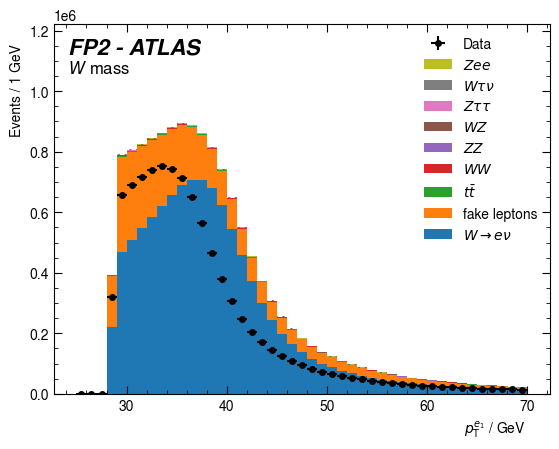

In [32]:
default_plot(h_pt, "$p_\mathrm{T}^{e_1}$ / GeV")
plt.savefig("plots/el_pt_prefit.pdf")
None

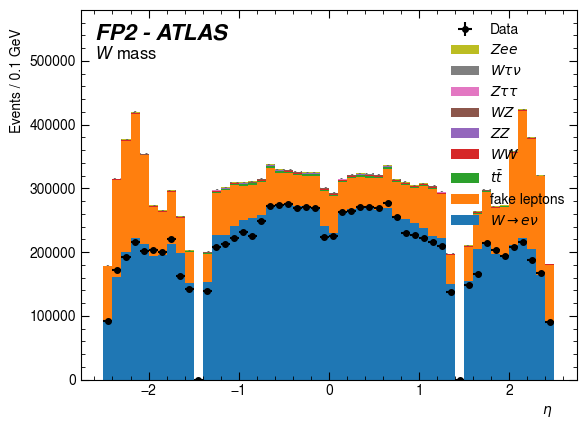

In [33]:
default_plot(h_eta, r"$\eta$")
plt.savefig("plots/eta.pdf")
None

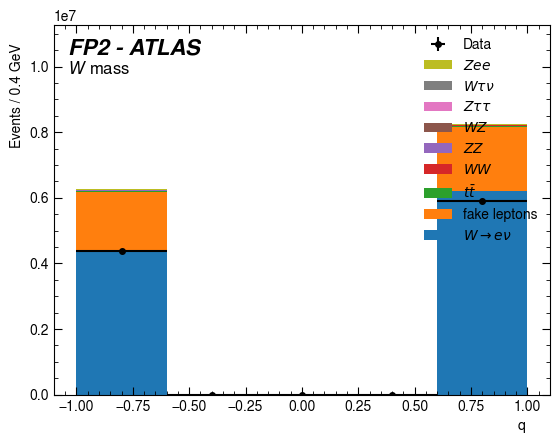

In [34]:
default_plot(h_chrg, r"q")
plt.savefig("plots/charge.pdf")

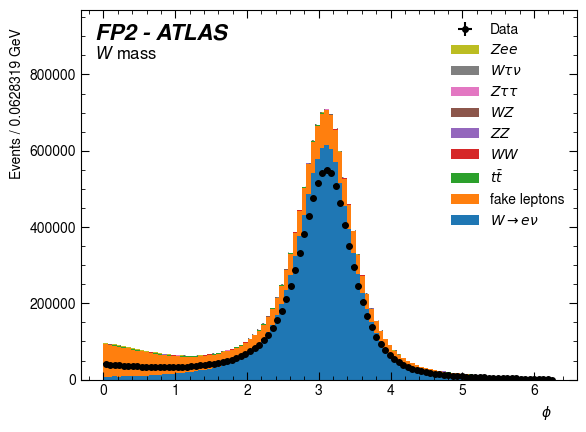

In [35]:
default_plot(h_dphi, r"$\phi$")
plt.savefig("plots/dphi.pdf")

# Reweighting W samples

![W sample reweighting sketch](notebook_figures/ReweightingSketch.png)

Ultimately we want to determine W mass by comparing the shapes of $p_T$ of electron for different mass hypothesis.
However, the problem is that we only have ntuples for $m_{W}=80.4$ GeV, `*PowHegWplusenuPythia*` and `*PowHegWminenuPythia*` once).
One natural approach would be to generate different set of ntuples for different mass hypothesis. 
The drawback of this approach, though, is that MC simulations that include full simulation of the detector response are very CPU & time consuming.
It takes around an hour for a full simulation of a single event \[[ref](https://doi.org/10.1016/j.nuclphysbps.2011.03.142)\]! Even for our relatively small sample size of few milion events that would be quite an endavour! 

What we would do instead is to reweight the existing samples. On the plot above you can see the idea behind the approach. The plot shows the **truth** invariant mass of lepton-neutrino pair coming from W decays for two different mass hypothesis. The distributions is given by Breit-Wigner distribution centered at the coresponding hypothesised masses. The reweighting factor needed to go from left ('old') to right ('new') distribution is given by $f(x)=\frac{N(x|m_{new})}{N(x|m_{old})}$.

<b>Assignment</b> Think and discuss with your tutor:
   * Can we reweight in the same way our data events?
   * We apply weights based on single distribution (i.e. in $m_{W}$(truth)). What is going to happen with other distributions? Do we need to reweightem separately as well?
   * what is the drawback of the reweighting method?

<b>Assignment</b> Please inspect the truth tree `truthTree` What variables do you have there?  

In [36]:
# TODO inspect truthTree for W samples
mc_analysis = fpu.Analysis(luminosity_fb=4.57944)
mc_analysis.add_sample(
    "Wen", r"$W\rightarrow e\nu$",
    [
        "/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108297.PowHegWplusenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root",
        "/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108300.PowHegWminenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root"
    ],
    xsec_fb=None,  
    meta_data={"fake": False, "data": False, "mc": True, "W": True}
)


for df, norm, meta_data, i in mc_analysis.dataframe_iterate(tree_name="truthTree", fraction=0.1):
    print(df.columns)
    break  

Index(['elGen_pt', 'elGen_eta', 'elGen_phi', 'elGen_charge', 'nuGen_pt',
       'nuGen_eta', 'nuGen_phi'],
      dtype='str')


## Truth MC sample

Follow the code below to get histograms with W reweighting factors making any modification you need along the way.

In [37]:
# Preview of Particle Physics, M. Tanabashi et al., Phys. Rev. D 98, 030001
m_e = 0.5109989461

In [38]:
# Since we need only W samples we create new `Analysis` object
truth_ana = fpu.Analysis(luminosity_fb=4.57944)

# W -> e nu
truth_ana.add_sample("Wen", r"$W\rightarrow e\nu$",
                     ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108297.PowHegWplusenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root"],
                     xsec_fb=6.16e6,
                     meta_data={"fake": False, "data": False, "mc": True})
truth_ana.add_sample("Wen", r"$W\rightarrow e\nu$",
                     ["/home/cl313/test/ATLAS/data/ntuple_part23/v5.mc11_7TeV.108300.PowHegWminenuPythia.e825_s1372_s1370_r3108_r3109_p1035.root"],
                     xsec_fb=4.30e6,
                     meta_data={"fake": False, "data": False, "mc": True})

In [39]:
# Defined new plotting function (necessary as we do not have data samples in our truth_ana)
def truth_plot(histogram, x_label, axes=None):
    if axes is None:
        fig, axes = plt.subplots()
        
    fpu.hist_stack(histogram, axes=axes)
    atlasify(subtext="$W$ mass",axes=axes)
    axes.set_xlabel(x_label, ha='right', x=0.95)
    bin_width = histogram.GetXaxis().GetBinWidth(1)
    axes.set_ylabel(f"Events / {bin_width:g} GeV", ha='right', y=0.95)
    return axes

In [40]:
# Define histograms containing the invariant mass of the W

h_mW = ROOT.TH1F("", "", 160, 70, 90)
# TODO inspect other kinematical variables in the truth trees


# Loop over truth MC only
for df, norm, meta_data, i in truth_ana.dataframe_iterate(tree_name="truthTree", fraction=0.1):
    print(df.columns)
    # Construct 4-momenta
    e_p4 = Momentum4.m_eta_phi_pt(m_e,
                                  df.elGen_eta,
                                  df.elGen_phi,
                                  df.elGen_pt)
    nu_p4 = Momentum4.m_eta_phi_pt(0,  # massless neutrino
                                   df.nuGen_eta,
                                   df.nuGen_phi,
                                   df.nuGen_pt)
    
    # Addition of Lorentz vectors and invarient mass computation
    mW = (e_p4 + nu_p4).m  
    
    # Fill histograms, we only have MC
    fpu.fill_histo(mW / 1000, h_mW, weights=norm * np.ones(len(df)))

Index(['elGen_pt', 'elGen_eta', 'elGen_phi', 'elGen_charge', 'nuGen_pt',
       'nuGen_eta', 'nuGen_phi'],
      dtype='str')
Index(['elGen_pt', 'elGen_eta', 'elGen_phi', 'elGen_charge', 'nuGen_pt',
       'nuGen_eta', 'nuGen_phi'],
      dtype='str')


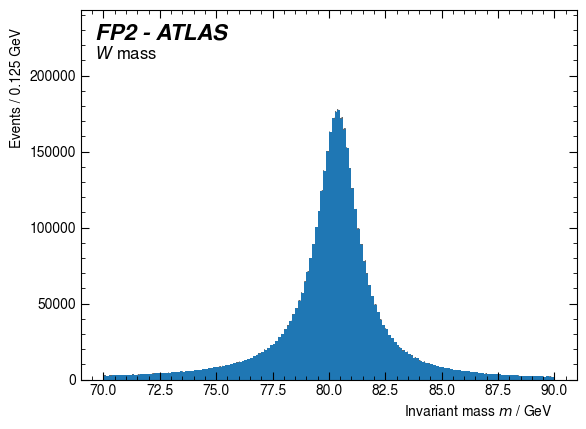

In [42]:
truth_plot(h_mW, "Invariant mass $m$ / GeV")
None

## Breit-Wigner template

In the following cell we are going to fit Breit-Wigner to our truth mW distribution
The fitted function (`breit_wigner` object defined below) is going to be used by us to calculate the weights.

In [43]:
# We fit expected Breit-Wigner to truth mW distribution
# ROOT is very handy for many typical particle physics workflows...

breit_wigner = ROOT.TF1("bw", "[0] * TMath::BreitWigner(x,[1],[2])", 70, 90)

# Set initial parameters
breit_wigner.SetParameters(h_mW.Integral(), 80, 2)

result = h_mW.Fit("bw", "S", "", 70, 90).Get()

# Copy best fit parameters to orignal model
for i in range(result.NPar()):
    breit_wigner.SetParameter(i, result.Parameter(i))

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      7464.37
NDf                       =          157
Edm                       =  2.50139e-07
NCalls                    =           93
p0                        =       598185   +/-   423.607     
p1                        =      80.3459   +/-   0.00103772  
p2                        =      2.16716   +/-   0.00229254  


Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1


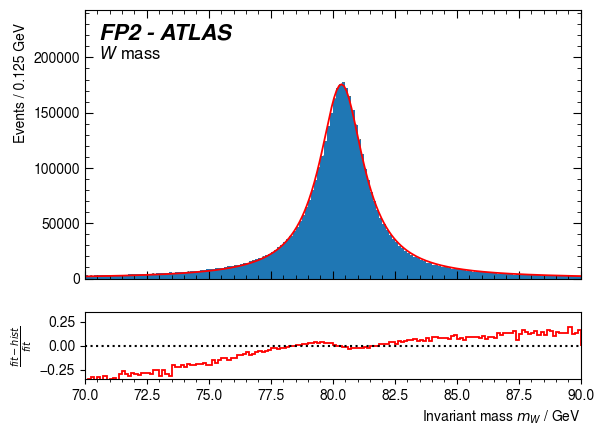

In [44]:
#Let's plot the fitted function & the ratio between fit and the histogram
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex='col', gridspec_kw={'height_ratios': [4, 1]})
truth_plot(h_mW, "",axes=ax1)
x_values_bw = np.linspace(60, 100, 400)
ax1.plot(x_values_bw, [breit_wigner.Eval(x) for x in x_values_bw],color='r',linewidth=1.3)
ax1.set_xlim((70, 90))
ax2.set_xlabel("Invariant mass $m_W$ / GeV",loc='right')

FitDiff=h_mW.Clone()
for bin in range(FitDiff.GetNbinsX()+1):
    val=FitDiff.GetBinContent(bin)
    binCenter=FitDiff.GetBinCenter(bin)
    FitDiff.SetBinContent(bin,(breit_wigner.Eval(binCenter)-val)/breit_wigner.Eval(binCenter))
fpu.hist_line(FitDiff,axes=ax2,color='r',linewidth=1.3)
plt.plot([70,90],[0,0],color='k',ls=':')
ax2.set_ylabel(r"$\frac{fit-hist}{fit}$",loc='center')
ax2.set_ylim(-0.35,0.35)
plt.savefig("plots/truthWmass_postFit.pdf")
None

# We will need edges of the bins later!
diff = x_values_bw[1] - x_values_bw[0]
x_edges_bw = np.linspace(min(x_values_bw) - diff / 2,
                         max(x_values_bw) + diff / 2,
                         len(x_values_bw) + 1)

<b>Assignment</b> Was the fit scucessful? Are values return from the fit make physical sense? What do they (or should) refer to? Thiscuss it with your tutor

## Extracting W weights 

In [48]:
# Here we create dictionary W_weights of pairs (mass, correction factor)


mass_points = np.linspace(70,90, 5) # weights will be generated for these masses


median_mass_point = mass_points[len(mass_points) // 2]
W_weights = {}

shifted_bw = breit_wigner.Clone()

for mass_point in mass_points:
    shifted_bw.SetParameter(1, mass_point)
    W_weights[mass_point] = [shifted_bw.Eval(x) / breit_wigner.Eval(x) for x in x_values_bw]

<b>Assignment</b> Please plot the W weights. Are they shaped as you would expected them to be?

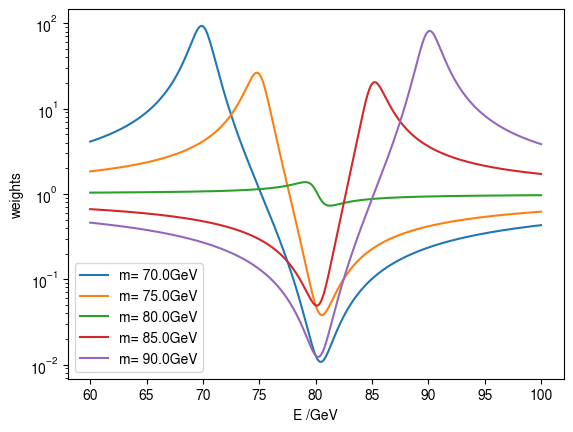

In [62]:
# TODO plot weights for different mass hypothesis

for mp in mass_points:

    plt.plot(x_values_bw,W_weights[mp], label='m= '+str(mp)+'GeV')

plt.xlabel('E /GeV')
plt.ylabel('weights')
plt.yscale('log')
plt.legend()

In [57]:
def calc_weight_idx(df_truth):
    # The function accepts df with truth entries and 
    # returns bin numbers of the weight histogram
    # corresponding to events invariant masses
     
    # Construct 4-momenta
    e_p4 = Momentum4.m_eta_phi_pt(m_e,
                                  df_truth.elGen_eta,
                                  df_truth.elGen_phi,
                                  df_truth.elGen_pt)
    nu_p4 = Momentum4.m_eta_phi_pt(m_e,  # massless neutrino
                                  df_truth.nuGen_eta,
                                  df_truth.nuGen_phi,
                                  df_truth.nuGen_pt)
    
    # Addition of Lorentz vectors and invarient mass computation
    mW = (e_p4 + nu_p4).m  
    
    weights_idx = np.searchsorted(x_edges_bw, mW / 1000) - 1
    return weights_idx

def apply_shift(mass_point, weight_idx):
    # Given requested mass and the bin numbers 
    # function returns corresponding weighting factors. 
    
    this_weights = W_weights[mass_point]

    reweighting = np.zeros(len(weight_idx))
    for bin_idx, weight in enumerate(this_weights):
        reweighting[bin_idx == weight_idx] = weight
        
    return reweighting

## Verify weight extraction

Are we getting what we wanted? Let's check if we get reasonable results

In [58]:
# Define histograms
h_mW_reweighted = {mass_point: ROOT.TH1F("", f"$m = {mass_point:.1f}$ GeV", 160, 70, 90)
                       for mass_point in mass_points}


# Loop over truth MC only
for df, norm, meta_data, i in truth_ana.dataframe_iterate(tree_name="truthTree", fraction=0.1):
    # Construct 4-momenta
    e_p4 = Momentum4.m_eta_phi_pt(m_e,
                                  df.elGen_eta,
                                  df.elGen_phi,
                                  df.elGen_pt)
    nu_p4 = Momentum4.m_eta_phi_pt(0,  # massless neutrino
                                   df.nuGen_eta,
                                   df.nuGen_phi,
                                   df.nuGen_pt)
    
    # Addition of Lorentz vectors and invarient mass computation
    mW = (e_p4 + nu_p4).m  
    
    weights_idx = np.searchsorted(x_edges_bw, mW / 1000) - 1
    
    for mass_point in mass_points:
        reweighting=apply_shift(mass_point, weights_idx)
        fpu.fill_histo(mW / 1000, h_mW_reweighted[mass_point], weights=norm * reweighting)

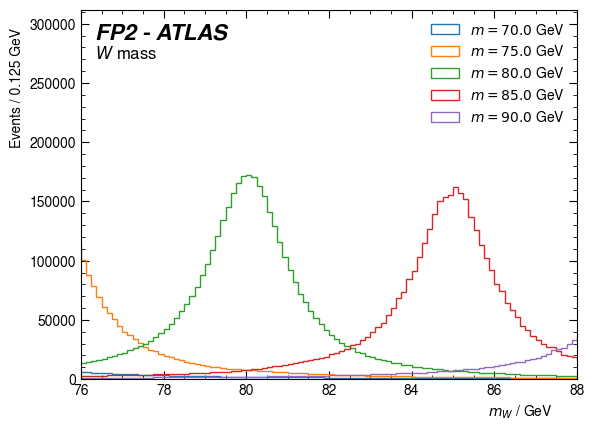

In [59]:
fig, axes = plt.subplots()
for mass_point, h in h_mW_reweighted.items():
    fpu.hist_line(h, axes=axes)
bin_width = h.GetXaxis().GetBinWidth(1)
plt.ylabel(f"Events / {bin_width} GeV", ha='right', y=0.95)
plt.xlabel("$m_W$ / GeV", ha='right', x=0.95)
plt.xlim((76, 88))
atlasify(subtext="$W$ mass", enlarge=1.2)

## Apply shift to the W samples

In [ ]:
# Define histograms
h_pt = analysis.TH1F_stack(45, 25, 70)
h_pt_W = {mass_point: ROOT.TH1F("", fr"$W\rightarrow e\nu$ ({mass_point:.1f} GeV)", 45, 25, 70)
                       for mass_point in mass_points}

# Loop over data and MC
for df, norm, meta_data, i in analysis.dataframe_iterate(fraction=0.1):
    
    # Apply cuts on events
    df=event_selection(df,meta_data)
    
    if meta_data["data"]:
        e1_E_calib = fpu.apply_calib(df.el1_cl_E, df.el1_cl_eta, alpha, eta_edges)
    else:
        #MC should not be calibrated
        e1_E_calib = df.el1_cl_E
            
    # Compute pT
    e1_pt = pt(e1_E_calib, df.el1_cl_eta)
        
    # Fill histograms
    if meta_data["mc"]:
        weights = df.mc_weight * norm
    elif meta_data["fake"]:
        weights = np.ones(len(df)) * wh_fake_factor
    else:
        weights = None
    
    if meta_data["W"]:
        # TODO Using weights & functions implemented above fill correctly h_pt_W[mass_point]
        e_p4 = Momentum4.m_eta_phi_pt(m_e, df.elGen_eta, df.elGen_phi, df.elGen_pt)
        nu_p4 = Momentum4.m_eta_phi_pt(0, df.nuGen_eta, df.nuGen_phi, df.nuGen_pt)

        mW_truth = (e_p4 + nu_p4).m / 1000   




        bin_index = np.searchsorted(x_values_bw, mW_truth) - 1
        
        for mass_point in mass_points:
            h = h_pt_W[mass_point]

            # lookup reweight factors
            reweights = np.array(W_weights[mass_point])[bin_index]

            # combine with MC normalization
            total_weights = weights * reweights

            fpu.fill_histo(e1_pt / 1000, h, weights=total_weights)


    else:
        fpu.fill_histo(e1_pt / 1000, h_pt[i], weights=weights)

In [65]:
# Let's organise the histograms a bit
# Please mind that this relies on correct sequence of calling add_samples 
# (first data, then W jets, then fakes then all the rest of the backgrounds...)
h_pt_data, h_pt_backgrounds = split(h_pt)
_, h_pt_non_W_bkgs = split(h_pt_backgrounds)  #  remove Wen
h_pt_fake_bkg, h_pt_other_bkgs = split(h_pt_non_W_bkgs)  #  remove fake

In [291]:
# TODO Please plot examples of W distributions for different mass hypotheses.

# Statistical Analysis

It is now time to determine mW by fitting different background hypotheses to data. 

Our model has two parameters of interests:
   1) mW 
   2) fake factor (ff)

We will estimate best parameter values with the negative log-likelohood (NLL) minimasation technique. 
NLL is one of the popular optimisation method. In special case, of binned data measurements characterised by Gaussian distributions, it coincides with, probably, more familiar least-square method. In more general case, NLL minimasation has slightly better properties being often a prefered choice within particle physics comunity.

Additional stat references: [PDG(statistics)](https://pdg.lbl.gov/2020/reviews/rpp2020-rev-statistics.pdf), [Practical Statistics for LHC](https://arxiv.org/abs/1503.07622)

## Background model specification

In [292]:
def background_model(fake_factor, W_mass, title=None):
    # The function takes fake_factor and Wmass as inputs and returns ROOT histogram 
    # coresponding to total background events with these parameter values.
    # Please mind that Wmass has to be one of the keys in h_pt_W dictionary!
    fake_histo = h_pt_fake_bkg.Clone()
    fake_histo.Scale(fake_factor / wh_fake_factor)
    total = sum_histograms(h_pt_other_bkgs + [fake_histo, h_pt_W[W_mass]])
    if title is not None:
        total.SetTitle(title)
    return total 

<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1962/492472543.py:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("Transverse momentum $p_{\mathrm{T}}^{e_1}$ / GeV", ha='right', x=0.95)


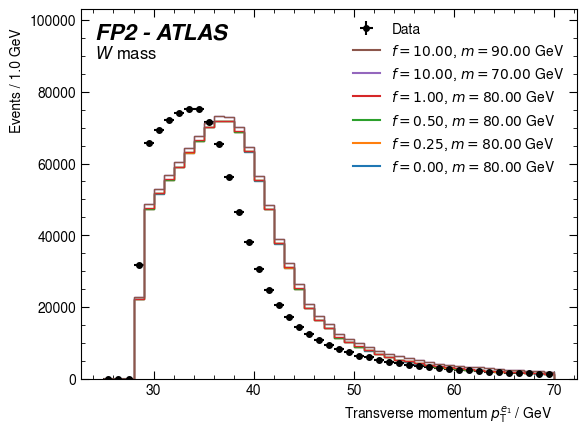

In [293]:
# We can then visualise this background model for different parameter values

fig, axes = plt.subplots()
fpu.hist_points(h_pt_data, axes=axes)

for fake_factor in [0, 0.25, 0.5, 1]: # You might have to adjust this 



    mass_point = median_mass_point
    title = f"$f={fake_factor:.2f}$, $m={mass_point:.2f}$ GeV"
    fpu.hist_line(background_model(fake_factor, mass_point, title), axes=axes)
        
for mass_point in [mass_points[0], mass_points[-1]]:
    fake_factor = 10
    title = f"$f={fake_factor:.2f}$, $m={mass_point:.2f}$ GeV"
    fpu.hist_line(background_model(fake_factor, mass_point, title), axes=axes)
    
fpu.reverse_legend() 
bin_width = h_pt_data.GetXaxis().GetBinWidth(1)
plt.ylabel(f"Events / {bin_width} GeV", ha='right', y=0.95)
plt.xlabel("Transverse momentum $p_{\mathrm{T}}^{e_1}$ / GeV", ha='right', x=0.95)
atlasify(subtext="$W$ mass")
plt.savefig("plots/h_el1_pt_BkgHypothesis.pdf")

<b> Assignment</b> Discuss with your lab-partner. Do the background curves have expected behaviour? What changes when you increase mW? What if you increase fake_factor?

## Negative Log Likelihood specification

One of the most crucial aspect of fitting is to specify/choose correct statistical model to be used. 
In our case we want to fit binned data to MC. Data in each bin is distributed according to Poisson distribution with the mean given by our background model. 
Since our background samples have limited statistics, the background predition in each bin comes with an associated statistical uncertainty. Our model takes this into account by allowing for the mean of the expected Poisson distribution in each bin to vary accordigly. In addition we will assume that per bin MC stat errors are given by Gaussian distributions (which is usually a very good assumption with a resonable MC size). So, our likelihood function can be written as:

$L(\theta)=\prod_{i=1}^{i\leq n} Pois(n_i|b_i+\gamma_i\sigma^{MC}_i)\cdot Gaus(\gamma_i,\mu=0,\sigma=1)$,

where\
$\theta$ $\equiv$ ($m_{W},f_{fake},\gamma_i$) -- parameters of our model,\
Pois(x|$\lambda$) -- Poisson probability distribution with the expected rate $\lambda$\
Gaus(x,$\mu$,$\sigma$) -- Gaussian probability distribution with mean $\mu$ and variance $\sigma^2$,\
$n$, the total number of bins in the histogram,\ 
$n_i$, number of data observed in each bin,\
$b_i$, expected number of MC events in each bin,\
$\sigma^{MC}_i$, MC stat error per bin ($1 \sigma$),\
$\gamma_i$, parametrise per-bin MC stat error. This parameter is constrained (because of our knowledge of total number of MC events and associated with this error) by the Gaussian term.

Taking -ln($L(\theta)$) we get what is specified in the function below:

In [294]:
def nll(data, fake_factor, W_mass, gammas, bin=None,background_model=background_model):
    # Function calculates negaitve log-likelihood of our background model
    # It requires: 1) data histogram, values of parameters 2) fake_factor 3) W mass, and 4) gamma (list)
    #    optionally accepts bin number for which to calculate the NLL, 
    #                                      and function which accepts fake_factor and W_mass creating expected bkg histogram
    nll = 0
    bkg = background_model(fake_factor, W_mass)
    for i, gamma in enumerate(gammas, 1):
        if bin is not None and i != bin:
            continue
        if data.GetBinContent(i) == 0:
            continue
        if bkg.GetBinContent(i) == 0:
            continue
        if bkg.GetBinError(i) == 0:
            continue
        nll -= poisson.logpmf(data.GetBinContent(i),
                              bkg.GetBinContent(i) + gamma * bkg.GetBinError(i))
        nll -= gauss.logpdf(gamma)
    return nll

Parameters $\gamma$ are constrained by the Gaussian terms and we can minimase against them first. This is now technically so called **profiled likelihood**.

In [295]:
n = h_pt_data.GetNbinsX()
def minimize_gammas(nll, h_pt_data, fake_factor, mass_point,background_model=background_model):
    # Function takes NLL function, data histogram, fake_factor, w mass, as well as, optionally 
    # a function which accepts fake_factor and W_mass creating expected bkg histogram. 
    #
    # minimize_gammas returns gamma factors minimising NLL function for given parameters. 
    #
    opt_g = []
    for i in range(n):
        nll_single_g =  lambda g: nll(h_pt_data, fake_factor, mass_point, [0]*i + [g] + [0]*(n-1-i), bin=i+1,\
                                    background_model=background_model)
        result = scipy.optimize.minimize(nll_single_g, x0=[0], bounds=[(-100, 100)])
        opt_g.append(result.x[0])
    return opt_g

## NLL minimalisation

We scan over mW and fake_factors to find the minimum this way

In [296]:
fake_factors = np.linspace(0, 1, 4)


nll_grid = np.zeros((len(fake_factors), len(mass_points)))
for i, fake_factor in enumerate(fake_factors):
    for j, mass_point in enumerate(mass_points):
        gammas = minimize_gammas(nll, h_pt_data, fake_factor, mass_point)
        nll_grid[i][j] = nll(h_pt_data, fake_factor, mass_point, gammas)

In [297]:
nll_interp = si.interp2d(mass_points, fake_factors, nll_grid, kind='cubic')

NotImplementedError: `interp2d` has been removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
https://scipy.github.io/devdocs/tutorial/interpolate/interp_transition_guide.html


In [ ]:
m_values = np.linspace(min(mass_points), max(mass_points), 1000)


ff_values = np.linspace(0, 1, 1000) # Adjust the range of the parameter depending on the range you scan on!


nll_grid_hr = nll_interp(m_values, ff_values)
nll_min = nll_grid_hr.min()
ff_opt_idx, mp_opt_idx = np.unravel_index(nll_grid_hr.argmin(), nll_grid_hr.shape)
ff_opt, mp_opt = ff_values[ff_opt_idx], m_values[mp_opt_idx]
ff_opt, mp_opt # our best estimates!!

## Visualising the results

Here we will touch upon extremely useful property of log-likelihood, i.e. **straightforward parameters error estimation**.\
In the nutshell 
<div style="border: 1px solid black; padding: 1em; width: 7cm">
$-ln L (\mathbf{\hat{a}}\pm n\mathbf{\sigma})=-ln L(\mathbf{\hat{a}}) +\frac{1}{2} n^2$,
</div>
where $\mathbf{a}$ is the parameter value at the minimum.

One can easily convince themselves of this result expanding likelihood around the minimum:\
$-lnL(\mathbf{a})=-lnL(\mathbf{\hat{a}})-\frac{1}{2}\frac{d^2 L}{da^2}\Big|_{\mathbf{a}=\mathbf{\hat{a}}} (\mathbf{a}-\mathbf{\hat{a}})^2+$higher order terms.\
This corresponds to $L(\mathbf{a})\approx C \cdot e^{-\frac{1}{2}\sigma^2(\mathbf{a}-\mathbf{\hat{a}})^2}$, so Gaussian distributed function with  $\sigma^2=1\Big/\Big(\frac{d^2 L}{da^2}\Big|_{\mathbf{a}=\mathbf{\hat{a}}}\Big)$.\
It should be clear now what the result is if $\mathbf{a}\to\mathbf{\hat{a}}+n\mathbf{\sigma}$. 

And, importantly, this back of the envelope calculation (for Gaussian likelihood) extends to any likelihood funtion thanks to NLL invariance property (solutions are invariant under the 1:1 change of parameters, e.g. if $\hat{a}$ is a solution f($\hat{a}$) is as well). And so, the results in the box hold true for non-Gaussian likelihoods, like for example the ones we have of products of Poisson & Gaussian functions! 

For those of you interested have a look at the great book [F. James, Statistical methods in experimental physics (2006), ISBN 9789812567956]

In [ ]:
# Here we visualise min logg-likelihood showing 1 and 2 sigma band for parameters of interest

plt.plot([mp_opt], [ff_opt], 'x', color='k')
contour = plt.contour(m_values, ff_values, nll_grid_hr - nll_min,
            levels=[0.5, 2], 
            colors=['orange', 'orange'],
            linestyles=['-', ':'])
plt.pcolormesh(m_values, ff_values, nll_grid_hr - nll_min, vmin=0, vmax=10,
               cmap='Blues',shading='auto')
cbar = plt.colorbar()
cbar.ax.set_ylabel(r"$-\log\,L$")

handles = contour.legend_elements()[0]
plt.legend(handles=handles, labels=[r"$1 \sigma$", r"$2 \sigma$"])

sigma1 = contour.allsegs[0][0]
mp_min, ff_min = sigma1.min(axis=0)
mp_max, ff_max = sigma1.max(axis=0)

sigma2 = contour.allsegs[1][0]
mp_min2, ff_min2 = sigma2.min(axis=0)
mp_max2, ff_max2 = sigma2.max(axis=0)


mp_dev2 = max(mp_max2 - mp_opt, mp_opt - mp_min2)
ff_dev2 = max(ff_max2 - ff_opt, ff_opt - ff_min2)

plt.xlim((mp_opt - mp_dev2*1.5, mp_opt + mp_dev2*1.5))
plt.ylim((ff_opt - ff_dev2*1.5, ff_opt + ff_dev2*1.5))

plt.xlabel("$m_W$ / GeV", ha='right', x=0.95)
plt.ylabel("$f$", ha='right', y=0.95)

atlasify(subtext="$W$ mass", outside=True)

In [ ]:
# We can also look at slices for fixed fake_factor value 

m_fine = np.linspace(mp_opt - mp_dev2 * 1.5, mp_opt + mp_dev2 * 1.5)
plt.plot(m_fine, [0.5]*len(m_fine), '-', color='orange')
plt.plot(m_fine, [2.0]*len(m_fine), ':', color='orange')
plt.plot(m_fine, nll_interp(m_fine, ff_opt) - nll_min,
             label=f"$f = {ff_opt:.2f}$")
plt.xlabel("$m_W$ / GeV", ha='right', x=0.95)
plt.ylabel(r"$-\log\,L$", ha='right', y=0.95)
plt.legend()
atlasify(subtext="$W$ mass")

In [ ]:
# Or slices for fixed mW value 

ff_fine = np.linspace(ff_opt - ff_dev2 * 1.5, ff_opt + ff_dev2 * 1.5)
plt.plot(ff_fine, [0.5]*len(ff_fine), '-', color='orange')
plt.plot(ff_fine, [2.0]*len(ff_fine), ':', color='orange')
plt.plot(ff_fine, nll_interp(mp_opt, ff_fine) - nll_min,
             label=f"$m = {mp_opt:.2f}$ GeV")
plt.xlabel("$f$", ha='right', x=0.95)
plt.ylabel(r"$-\log\,L$", ha='right', y=0.95)
plt.legend()
atlasify(subtext="$W$ mass")

Our results in a nice form

In [ ]:
from IPython.display import display, Latex
display(Latex(fr"$m_{{W}}={mp_opt:.3f} ^{{+ {mp_max - mp_opt:.3f}}} _{{- {mp_opt - mp_min:.3f}}}\,\mathrm{{GeV}}$"))
from IPython.display import display, Latex
display(Latex(fr"$f={ff_opt:.3f} ^{{+ {ff_max - ff_opt:.3f}}} _{{- {ff_opt - ff_min:.3f}}}$"))

<b>Assignment</b> Did you get the resutls? Think about them & discuss your findings with lab partner & your tutor. In particulary:

* How are your values compare to the public results? 
* Are your error estimation reasonable? What additional sources of error could/should be included?
* Can you improve the results further? How?

# Post fit results

Minimum log-likelihood on its own does not provide us information how good the expected model fits the data. 
It only gives us estimation for parameters of the model that fit the data best. The best fitted values can still be off from the measurements though.\
To make matter worst, the error estimations on the parameters we have obtained are only correct if the underlaying model is correct. This should be clear intuitavely, as the fit cannot account for things it does not know about.

Therefore after a fit one needs to verify that it behaves resonably and thus the results are sensible. Ideally we would calculate p-value for our profiled-likelihood. This goes beyond the scope of this lab, though, and we will 'just' plot the 'post-fit' results judging by eye how well data agrees with MC.

<b>Assignment</b> Please plot several kinematic distributions for the mW and fake_factor found in the fit. Is the level of agreement acceptable?

In [ ]:
# TODO plot post fit results. 